Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Libraries loaded
Judges: 98,478
Lazy plan built (nothing materialised yet)


/home/spark-dcc29db0-c167-4a6d-8529-24/.ipykernel/75/command-6955643885796236-1541050457:106: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


Collected shape: (1200000, 7)
In-memory size: 55 MB
X: (1200000, 6)  29 MB
y: (1200000,)
Train: 960,000   Test: 240,000
Model trained

REGRESSION RESULTS
R2   : 0.466
RMSE : 486 days
MAE  : 352 days
Trained on 960,000 cases



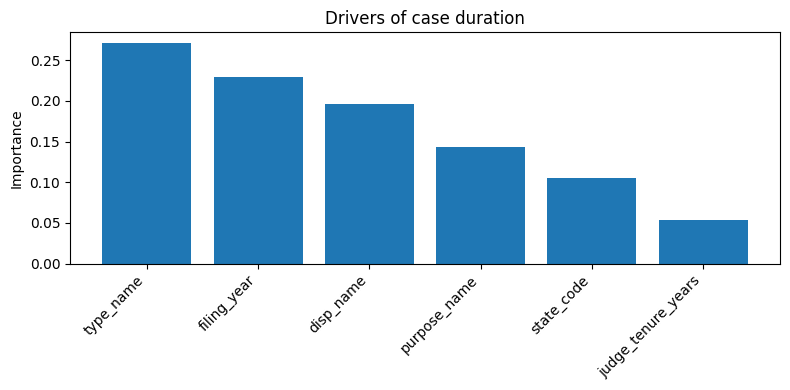

type_name              0.271
filing_year            0.230
disp_name              0.197
purpose_name           0.143
state_code             0.106
judge_tenure_years     0.054


In [0]:
# Databricks notebook source
# MAGIC %md
# MAGIC # 4. Regression Model — Predicting Case Duration (days)
# MAGIC Memory-safe version for Community Edition single-node driver.

# COMMAND ----------

%pip install polars pandas scikit-learn matplotlib seaborn

# COMMAND ----------

import gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

BASE = "/Workspace/Users/sumedha190198@gmail.com/judicial-backlog"

# Tune this down if you still OOM. 1_200_000 fits comfortably in CE.
N_SAMPLE = 1_200_000
SEED = 42

print("Libraries loaded")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Load reference data (small — safe to collect eagerly)

# COMMAND ----------

judges = pl.read_csv(f"{BASE}/judges_clean.csv").with_columns([
    pl.col("start_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_start"),
    pl.col("end_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_end"),
])

judges_lazy = judges.lazy().select([
    "state_code", "dist_code", "court_no", "judge_position", "judge_start"
])

print(f"Judges: {judges.height:,}")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Build the lazy feature pipeline
# MAGIC Nothing is materialised in this cell — the plan is only executed at collect().

# COMMAND ----------

FEATURES = [
    "judge_tenure_years",
    "type_name",
    "purpose_name",
    "disp_name",
    "filing_year",
    "state_code",
]
TARGET = "duration_days"

lf = (
    pl.scan_parquet(f"{BASE}/cases_sample_10pct.parquet")
    .filter(
        (pl.col("duration_days") >= 0)
        & (pl.col("duration_days") <= 7300)
    )
    .with_columns([
        pl.col("disp_name").cast(pl.Int64),
        pl.col("type_name").cast(pl.Int64),
        pl.col("purpose_name").cast(pl.Int64),
    ])
    .join(
        judges_lazy,
        on=["state_code", "dist_code", "court_no", "judge_position"],
        how="left",
    )
    .with_columns([
        pl.col("filing_date").dt.year().alias("filing_year"),
        (pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year())
        .alias("judge_tenure_years"),
    ])
    # CRITICAL: narrow to model columns BEFORE collecting.
    .select(FEATURES + [TARGET])
    .drop_nulls()
)

print("Lazy plan built (nothing materialised yet)")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Sample inside the plan, then collect once
# MAGIC This is the step that was previously OOMing. Row reduction now happens
# MAGIC before materialisation instead of after.

# COMMAND ----------

df = (
    lf.with_columns(pl.int_range(pl.len(), dtype=pl.UInt32).alias("_rn"))
      .filter(pl.col("_rn") % 7 == 0)     # deterministic ~1-in-7 thinning
      .drop("_rn")
      .head(N_SAMPLE)
      .collect(streaming=True)
)

print(f"Collected shape: {df.shape}")
print(f"In-memory size: {df.estimated_size('mb'):.0f} MB")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Convert straight to float32 NumPy (skip pandas entirely)

# COMMAND ----------

X = df.select(FEATURES).to_numpy().astype(np.float32)
y = df.select(TARGET).to_numpy().ravel().astype(np.float32)

# Release the Polars frame before training allocates.
del df
gc.collect()

print(f"X: {X.shape}  {X.nbytes / 1e6:.0f} MB")
print(f"y: {y.shape}")

# COMMAND ----------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

del X, y
gc.collect()

print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Train — capped depth and limited parallelism
# MAGIC max_depth is the single most important memory control here. An unbounded
# MAGIC tree on a million rows allocates roughly one leaf per sample.

# COMMAND ----------

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=50,
    max_features="sqrt",
    n_jobs=2,             # NOT -1: each worker copies the training array
    random_state=SEED,
)

rf.fit(X_train, y_train)
print("Model trained")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Evaluate

# COMMAND ----------

pred = rf.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
mae = mean_absolute_error(y_test, pred)

print(f"""
REGRESSION RESULTS
==================
R2   : {r2:.3f}
RMSE : {rmse:.0f} days
MAE  : {mae:.0f} days
Trained on {X_train.shape[0]:,} cases
""")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Feature importance

# COMMAND ----------

order = np.argsort(rf.feature_importances_)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(
    [FEATURES[i] for i in order],
    rf.feature_importances_[order],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Drivers of case duration")
plt.tight_layout()
plt.show()

for i in order:
    print(f"{FEATURES[i]:<22} {rf.feature_importances_[i]:.3f}")